<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/02.circuits-and-encoding/02.feature-encoding/day18_04_01_frequency_encoding_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day18 frequency encoding 실습

- Source: Google Drive `Day18/4-1.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 1. Input Feature
Input Feature x = 0.25


STEP 2. Frequency List
[1, 2, 3, 4, 5]


Frequency = 1 Hz
Rotation Angle = 1.5708 rad
Rotation Angle = 90.00 degree

Quantum Circuit
   ┌─────────┐
q: ┤ Ry(π/2) ├
   └─────────┘

Statevector
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Measurement
{'0': 2074, '1': 2022}

Probability
P(0) = 0.5063
P(1) = 0.4937

Expectation
Experiment : 0.0127
Theory     : 0.0000


Frequency = 2 Hz
Rotation Angle = 3.1416 rad
Rotation Angle = 180.00 degree

Quantum Circuit
   ┌───────┐
q: ┤ Ry(π) ├
   └───────┘

Statevector
Statevector([6.123234e-17+0.j, 1.000000e+00+0.j],
            dims=(2,))



Measurement
{'1': 4096}

Probability
P(0) = 0.0000
P(1) = 1.0000

Expectation
Experiment : -1.0000
Theory     : -1.0000


Frequency = 3 Hz
Rotation Angle = 4.7124 rad
Rotation Angle = 270.00 degree

Quantum Circuit
   ┌──────────┐
q: ┤ Ry(3π/2) ├
   └──────────┘

Statevector
Statevector([-0.70710678+0.j,  0.70710678+0.j],
            dims=(2,))



Measurement
{'1': 2038, '0': 2058}

Probability
P(0) = 0.5024
P(1) = 0.4976

Expectation
Experiment : 0.0049
Theory     : -0.0000


Frequency = 4 Hz
Rotation Angle = 6.2832 rad
Rotation Angle = 360.00 degree

Quantum Circuit
   ┌────────┐
q: ┤ Ry(2π) ├
   └────────┘

Statevector
Statevector([-1.0000000e+00+0.j,  1.2246468e-16+0.j],
            dims=(2,))



Measurement
{'0': 4096}

Probability
P(0) = 1.0000
P(1) = 0.0000

Expectation
Experiment : 1.0000
Theory     : 1.0000


Frequency = 5 Hz
Rotation Angle = 7.8540 rad
Rotation Angle = 450.00 degree

Quantum Circuit
   ┌──────────┐
q: ┤ Ry(5π/2) ├
   └──────────┘

Statevector
Statevector([-0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))



Measurement
{'1': 2023, '0': 2073}

Probability
P(0) = 0.5061
P(1) = 0.4939

Expectation
Experiment : 0.0122
Theory     : 0.0000


Summary
Frequency	Experiment	Theory
1		0.0127		0.0000
2		-1.0000		-1.0000
3		0.0049		-0.0000
4		1.0000		1.0000
5		0.0122		0.0000


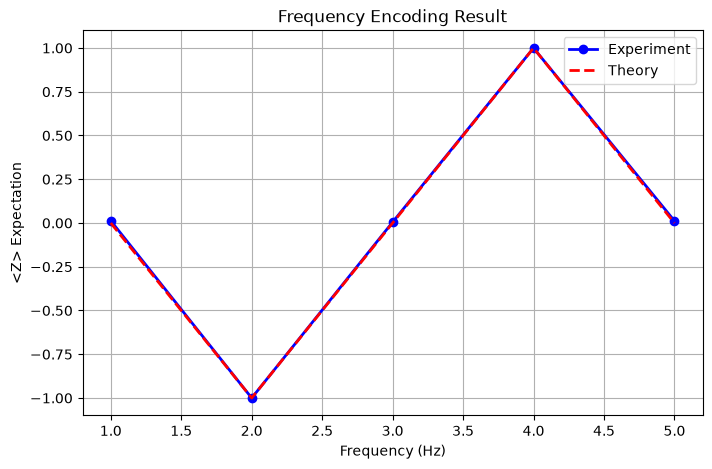


실습 완료


In [1]:
"""
==========================================================
Frequency Encoding 구현 실습
==========================================================
"""

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_bloch_multivector

# -------------------------------------------------------
# STEP 1
# 입력 데이터
# -------------------------------------------------------

print("=" * 60)
print("STEP 1. Input Feature")
print("=" * 60)

x = 0.25

print(f"Input Feature x = {x}")

# -------------------------------------------------------
# STEP 2
# Frequency 목록
# -------------------------------------------------------

print("\n")
print("=" * 60)
print("STEP 2. Frequency List")
print("=" * 60)

frequency_list = [1, 2, 3, 4, 5]

print(frequency_list)

# 결과 저장용

expectation_list = []
theory_list = []

backend = AerSimulator()

# -------------------------------------------------------
# STEP 3
# Frequency 반복
# -------------------------------------------------------

for f in frequency_list:

    print("\n")
    print("=" * 60)
    print(f"Frequency = {f} Hz")
    print("=" * 60)

    # -----------------------------------------------
    # STEP 4
    # Rotation Angle
    # -----------------------------------------------

    theta = 2 * np.pi * f * x

    print(f"Rotation Angle = {theta:.4f} rad")
    print(f"Rotation Angle = {np.degrees(theta):.2f} degree")

    # -----------------------------------------------
    # STEP 5
    # Quantum Circuit
    # -----------------------------------------------

    qc = QuantumCircuit(1)

    # Frequency Encoding
    qc.ry(theta, 0)

    print("\nQuantum Circuit")
    print(qc.draw())

    # -----------------------------------------------
    # STEP 6
    # Statevector 확인
    # -----------------------------------------------

    state = Statevector.from_instruction(qc)

    print("\nStatevector")

    print(state)

    # Bloch Sphere

    plot_bloch_multivector(state)

    plt.show()

    # -----------------------------------------------
    # STEP 7
    # Measurement
    # -----------------------------------------------

    qc.measure_all()

    tqc = transpile(qc, backend)

    job = backend.run(tqc, shots=4096)

    result = job.result()

    counts = result.get_counts()

    print("\nMeasurement")

    print(counts)

    # -----------------------------------------------
    # STEP 8
    # Probability 계산
    # -----------------------------------------------

    shots = sum(counts.values())

    p0 = counts.get('0', 0) / shots
    p1 = counts.get('1', 0) / shots

    print("\nProbability")

    print(f"P(0) = {p0:.4f}")
    print(f"P(1) = {p1:.4f}")

    # -----------------------------------------------
    # STEP 9
    # Expectation 계산
    # -----------------------------------------------

    expectation = p0 - p1

    theory = np.cos(theta)

    expectation_list.append(expectation)

    theory_list.append(theory)

    print("\nExpectation")

    print(f"Experiment : {expectation:.4f}")
    print(f"Theory     : {theory:.4f}")

# -------------------------------------------------------
# STEP 10
# 결과 출력
# -------------------------------------------------------

print("\n")
print("=" * 60)
print("Summary")
print("=" * 60)

print("Frequency\tExperiment\tTheory")

for f, e, t in zip(frequency_list,
                   expectation_list,
                   theory_list):

    print(f"{f}\t\t{e:.4f}\t\t{t:.4f}")

# -------------------------------------------------------
# STEP 11
# 그래프
# -------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    frequency_list,
    expectation_list,
    'bo-',
    linewidth=2,
    label="Experiment"
)

plt.plot(
    frequency_list,
    theory_list,
    'r--',
    linewidth=2,
    label="Theory"
)

plt.xlabel("Frequency (Hz)")

plt.ylabel("<Z> Expectation")

plt.title("Frequency Encoding Result")

plt.grid(True)

plt.legend()

plt.show()

print("\n실습 완료")
